In [1]:
from pathlib import Path
import sys

# Ensure parent directory is on sys.path so we can import q_learning from the project root
sys.path.insert(0, str(Path.cwd().parent.resolve()))

from algorithms.q_learning import QLearningAgent, linear_decay_schedule
from buy_sell_env import BuySellEnv
import numpy as np
import matplotlib.pyplot as plt
from evaluator import PolicyEvaluator

In [13]:
class visualizer:
    def __init__(self, env, agent, optimal_policy=None):
        self.env = env
        self.agent = agent
        self.optimal_policy = env.solve_optimal_policy()[1] if optimal_policy is None else optimal_policy
    
    def plot_visit_counts(self):
        offer_visit_counts = (self.agent.visit_counts.sum(axis=(1,2)))
        plt.bar(range(len(offer_visit_counts)), offer_visit_counts)
        plt.xlabel('Offer Value Index')
        plt.ylabel('Number of Visits')
        plt.title('State Visit Counts by Offer Value (Sanity check)')
        plt.show()
    
    def plot_episode_rewards(self, rolling_window=100):
        rewards = self.agent.episode_rewards
        # rolling average over 100 episodes
        rewards = np.convolve(rewards, np.ones(rolling_window)/rolling_window, mode='valid')
        plt.plot(rewards)
        plt.xlabel('Episode')
        plt.ylabel('Total Reward')
        plt.title('Episode Rewards over Time')
        plt.show()

    def visualise_Q_table(self):
        Q_table = self.agent.Q
        # Exclude time_left=0 by slicing from index 1
        Q_table_view = Q_table[:, 1:, :, :]  # Start from time_left=1
        
        # ensure a common color scale across all subplots
        vmin = np.nanmin(Q_table_view)
        vmax = np.nanmax(Q_table_view)
        
        # Get the actual time_left range (1 to max_time)
        max_time = Q_table_view.shape[1]
        time_ticks = np.arange(0, max_time, max(1, max_time//10))  # Positions (0-indexed in plot)
        time_labels = np.arange(1, max_time+1, max(1, max_time//10))  # Labels (actual time_left values)

        fig, axs = plt.subplots(2, 2, figsize=(12, 10))
        ims = []
        
        # Yet to sell (stops_left=1), reject
        ims.append(axs[0, 0].imshow(Q_table_view[:, :, 1, 0], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto', origin='lower'))
        axs[0, 0].set_title('Q-values - Yet to sell, reject', fontsize=11, fontweight='bold')
        axs[0, 0].set_xlabel('Time Left', fontsize=10)
        axs[0, 0].set_ylabel('Offer Value Index', fontsize=10)
        axs[0, 0].set_xticks(time_ticks)
        axs[0, 0].set_xticklabels(time_labels)

        # Yet to sell (stops_left=1), accept
        ims.append(axs[0, 1].imshow(Q_table_view[:, :, 1, 1], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto', origin='lower'))
        axs[0, 1].set_title('Q-values - Yet to sell, accept', fontsize=11, fontweight='bold')
        axs[0, 1].set_xlabel('Time Left', fontsize=10)
        axs[0, 1].set_ylabel('Offer Value Index', fontsize=10)
        axs[0, 1].set_xticks(time_ticks)
        axs[0, 1].set_xticklabels(time_labels)

        # Yet to buy (stops_left=2), reject
        ims.append(axs[1, 0].imshow(Q_table_view[:, :, 2, 0], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto', origin='lower'))
        axs[1, 0].set_title('Q-values - Yet to buy, reject', fontsize=11, fontweight='bold')
        axs[1, 0].set_xlabel('Time Left', fontsize=10)
        axs[1, 0].set_ylabel('Offer Value Index', fontsize=10)
        axs[1, 0].set_xticks(time_ticks)
        axs[1, 0].set_xticklabels(time_labels)

        # Yet to buy (stops_left=2), accept
        ims.append(axs[1, 1].imshow(Q_table_view[:, :, 2, 1], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto', origin='lower'))
        axs[1, 1].set_title('Q-values - Yet to buy, accept', fontsize=11, fontweight='bold')
        axs[1, 1].set_xlabel('Time Left', fontsize=10)
        axs[1, 1].set_ylabel('Offer Value Index', fontsize=10)
        axs[1, 1].set_xticks(time_ticks)
        axs[1, 1].set_xticklabels(time_labels)

        # reserve space on the right for the colorbar and use a dedicated axis so the colorbar aligns nicely
        plt.tight_layout(rect=[0, 0, 0.92, 1])
        cax = fig.add_axes([0.94, 0.15, 0.02, 0.7])  # [left, bottom, width, height] in figure coords
        cb = fig.colorbar(ims[0], cax=cax, orientation='vertical')
        cb.set_label('Q-value', fontsize=10)

        plt.show()

    def visualise_policy(self):
        """
        Visualize the learned policy for buy and sell decisions.
        Shows accept (1) vs reject (0) decisions based on argmax of Q-values.
        """
        # Get policy from Q-table (argmax over actions)
        policy = self.agent.get_policy()  # shape: (n_states, max_time+1, max_stops+1)
        
        # Create figure with two subplots (one for buy, one for sell)
        fig, axs = plt.subplots(1, 2, figsize=(14, 5))
        
        # Policy for buying (stops_left = 2), exclude time_left=0
        policy_buy = policy[:, 1:, 2]  # (n_states, max_time)
        max_time = policy_buy.shape[1]
        time_ticks = np.arange(0, max_time, max(1, max_time//10))
        time_labels = np.arange(1, max_time+1, max(1, max_time//10))
        
        im1 = axs[0].imshow(policy_buy, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[0].set_xlabel('Time Left', fontsize=12)
        axs[0].set_ylabel('Offer Value Index', fontsize=12)
        axs[0].set_title('Buy Policy (First Stop)\nGreen=Accept, Red=Reject', fontsize=13, fontweight='bold')
        axs[0].grid(False)
        axs[0].set_xticks(time_ticks)
        axs[0].set_xticklabels(time_labels)
        
        # Add colorbar for buy policy
        cbar1 = plt.colorbar(im1, ax=axs[0], orientation='vertical', pad=0.02)
        cbar1.set_ticks([0, 1])
        cbar1.set_ticklabels(['Reject (0)', 'Accept (1)'])
        
        # Policy for selling (stops_left = 1), exclude time_left=0
        policy_sell = policy[:, 1:, 1]  # (n_states, max_time)
        im2 = axs[1].imshow(policy_sell, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[1].set_xlabel('Time Left', fontsize=12)
        axs[1].set_ylabel('Offer Value Index', fontsize=12)
        axs[1].set_title('Sell Policy (Second Stop)\nGreen=Accept, Red=Reject', fontsize=13, fontweight='bold')
        axs[1].grid(False)
        axs[1].set_xticks(time_ticks)
        axs[1].set_xticklabels(time_labels)
        
        # Add colorbar for sell policy
        cbar2 = plt.colorbar(im2, ax=axs[1], orientation='vertical', pad=0.02)
        cbar2.set_ticks([0, 1])
        cbar2.set_ticklabels(['Reject (0)', 'Accept (1)'])
        
        plt.tight_layout()
        plt.show()
        
        # Print some statistics
        print("\nQ-Learning Policy Statistics:")
        print(f"Buy Policy - Accept rate: {policy_buy.mean():.2%}")
        print(f"Sell Policy - Accept rate: {policy_sell.mean():.2%}")

    def compare_with_optimal(self):
        """
        Compare Q-learning policy with optimal DP policy.
        """
        if self.optimal_policy is None:
            print("⚠ Optimal policy not provided.")
            print("  Compute it first: V, opt_policy = env.solve_optimal_policy()")
            print("  Then: viz = visualizer(env, agent, optimal_policy=opt_policy)")
            return
        
        # Get policies
        q_policy = self.agent.get_policy()  # Q-learning policy
        opt_policy = self.optimal_policy  # Optimal policy
        
        # Exclude time_left=0
        q_policy_view = q_policy[:, 1:, :]
        opt_policy_view = opt_policy[:, 1:, :]
        
        max_time = q_policy_view.shape[1]
        time_ticks = np.arange(0, max_time, max(1, max_time//10))
        time_labels = np.arange(1, max_time+1, max(1, max_time//10))
        
        # Create comparison figure
        fig, axs = plt.subplots(2, 3, figsize=(18, 10))
        fig.suptitle('Policy Comparison: Q-Learning vs Optimal DP', fontsize=16, fontweight='bold')
        
        # Row 1: Buy policies (stops_left=2)
        # Q-learning buy policy
        im1 = axs[0, 0].imshow(q_policy_view[:, :, 2], cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[0, 0].set_title('Q-Learning: Buy Policy', fontsize=11, fontweight='bold')
        axs[0, 0].set_xlabel('Time Left', fontsize=10)
        axs[0, 0].set_ylabel('Offer Index', fontsize=10)
        axs[0, 0].set_xticks(time_ticks)
        axs[0, 0].set_xticklabels(time_labels)
        plt.colorbar(im1, ax=axs[0, 0], ticks=[0, 1], label='Action')
        
        # Optimal buy policy
        im2 = axs[0, 1].imshow(opt_policy_view[:, :, 2], cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[0, 1].set_title('Optimal: Buy Policy', fontsize=11, fontweight='bold')
        axs[0, 1].set_xlabel('Time Left', fontsize=10)
        axs[0, 1].set_ylabel('Offer Index', fontsize=10)
        axs[0, 1].set_xticks(time_ticks)
        axs[0, 1].set_xticklabels(time_labels)
        plt.colorbar(im2, ax=axs[0, 1], ticks=[0, 1], label='Action')
        
        # Difference (buy)
        diff_buy = (q_policy_view[:, :, 2] != opt_policy_view[:, :, 2]).astype(float)
        im3 = axs[0, 2].imshow(diff_buy, cmap='Reds', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[0, 2].set_title(f'Difference (Buy)\nMismatch: {diff_buy.mean():.1%}', fontsize=11, fontweight='bold')
        axs[0, 2].set_xlabel('Time Left', fontsize=10)
        axs[0, 2].set_ylabel('Offer Index', fontsize=10)
        axs[0, 2].set_xticks(time_ticks)
        axs[0, 2].set_xticklabels(time_labels)
        plt.colorbar(im3, ax=axs[0, 2], ticks=[0, 1], label='Different')
        
        # Row 2: Sell policies (stops_left=1)
        # Q-learning sell policy
        im4 = axs[1, 0].imshow(q_policy_view[:, :, 1], cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[1, 0].set_title('Q-Learning: Sell Policy', fontsize=11, fontweight='bold')
        axs[1, 0].set_xlabel('Time Left', fontsize=10)
        axs[1, 0].set_ylabel('Offer Index', fontsize=10)
        axs[1, 0].set_xticks(time_ticks)
        axs[1, 0].set_xticklabels(time_labels)
        plt.colorbar(im4, ax=axs[1, 0], ticks=[0, 1], label='Action')
        
        # Optimal sell policy
        im5 = axs[1, 1].imshow(opt_policy_view[:, :, 1], cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[1, 1].set_title('Optimal: Sell Policy', fontsize=11, fontweight='bold')
        axs[1, 1].set_xlabel('Time Left', fontsize=10)
        axs[1, 1].set_ylabel('Offer Index', fontsize=10)
        axs[1, 1].set_xticks(time_ticks)
        axs[1, 1].set_xticklabels(time_labels)
        plt.colorbar(im5, ax=axs[1, 1], ticks=[0, 1], label='Action')
        
        # Difference (sell)
        diff_sell = (q_policy_view[:, :, 1] != opt_policy_view[:, :, 1]).astype(float)
        im6 = axs[1, 2].imshow(diff_sell, cmap='Reds', vmin=0, vmax=1, aspect='auto', origin='lower')
        axs[1, 2].set_title(f'Difference (Sell)\nMismatch: {diff_sell.mean():.1%}', fontsize=11, fontweight='bold')
        axs[1, 2].set_xlabel('Time Left', fontsize=10)
        axs[1, 2].set_ylabel('Offer Index', fontsize=10)
        axs[1, 2].set_xticks(time_ticks)
        axs[1, 2].set_xticklabels(time_labels)
        plt.colorbar(im6, ax=axs[1, 2], ticks=[0, 1], label='Different')
        
        plt.tight_layout()
        plt.show()
        
        # Print detailed statistics
        print("\n" + "="*60)
        print("Policy Comparison Statistics")
        print("="*60)
        print(f"\nBuy Policy (stops_left=2):")
        print(f"  Q-Learning accept rate: {q_policy_view[:, :, 2].mean():.2%}")
        print(f"  Optimal accept rate: {opt_policy_view[:, :, 2].mean():.2%}")
        print(f"  Agreement: {(1 - diff_buy.mean()):.2%}")
        print(f"  Mismatch: {diff_buy.mean():.2%}")
        
        print(f"\nSell Policy (stops_left=1):")
        print(f"  Q-Learning accept rate: {q_policy_view[:, :, 1].mean():.2%}")
        print(f"  Optimal accept rate: {opt_policy_view[:, :, 1].mean():.2%}")
        print(f"  Agreement: {(1 - diff_sell.mean()):.2%}")
        print(f"  Mismatch: {diff_sell.mean():.2%}")
        
        # Overall agreement
        total_agreement = 1 - (diff_buy.sum() + diff_sell.sum()) / (diff_buy.size + diff_sell.size)
        print(f"\nOverall Policy Agreement: {total_agreement:.2%}")
        print("="*60)
    
    def pipeline(self, compare_optimal=True):
        self.plot_visit_counts()
        self.plot_episode_rewards()
        self.visualise_Q_table()
        self.visualise_policy()
        if compare_optimal and self.optimal_policy is not None:
            self.compare_with_optimal()


### Checking everything with a small example

In [22]:
n_states = 5
max_time = 10
max_stops = 2
Q_init = np.zeros((n_states, max_time + 1, max_stops + 1, 2)) 
holding_cost_per_step = 0.2

for i in range(n_states):
    Q_init[i,1:,1,1] = i

for i in range(n_states):
    Q_init[i,1,2,1] = -i - holding_cost_per_step




In [23]:
buy_sell_simple_env = BuySellEnv(n_states=5, max_time=10, transition_model='iid_gaussian', holding_cost_per_step=holding_cost_per_step)
asched = linear_decay_schedule(1.0, 0.01, 10000)
esched = linear_decay_schedule(1.0, 0.1, 10000)
agent = QLearningAgent(env=buy_sell_simple_env, alpha_schedule=asched, epsilon_schedule=esched, Q_init=Q_init)

In [24]:
results = agent.train(env=buy_sell_simple_env, n_episodes=1000000, verbose = 0 , use_tqdm=True)
viz = visualizer(buy_sell_simple_env, agent)

Training:   0%|                                                    | 0/1000000 [00:00<?, ?episode/s]

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 2.6302
  Buy (stop 1) accept rate: 42.00%
  Sell (stop 2) accept rate: 40.00%


In [6]:
# policy = agent.get_policy()
# print(policy[3,11,0])  # Policy for offer value index 3,
env = buy_sell_simple_env
V,P = env.solve_optimal_policy()
print(P[2,:,2])

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 3.2932
  Buy (stop 1) accept rate: 42.00%
  Sell (stop 2) accept rate: 30.00%
[0 0 1 1 1 0 0 0 0 0 0]


#### Sanity check - Visited states distribution

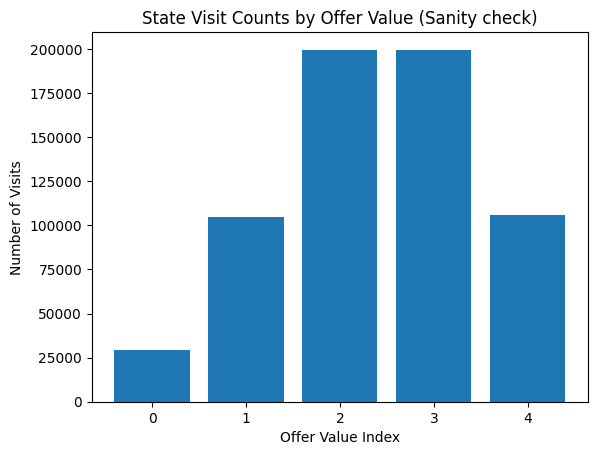

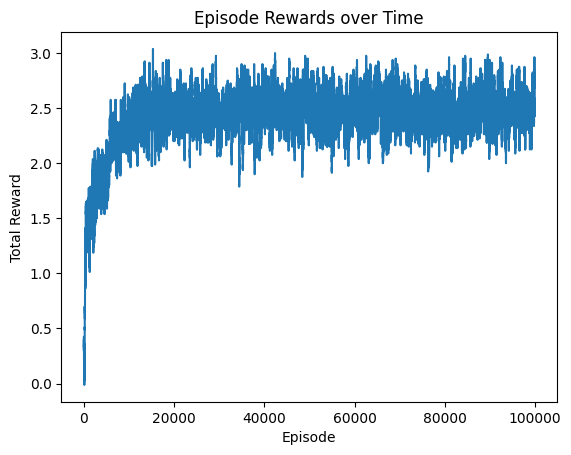

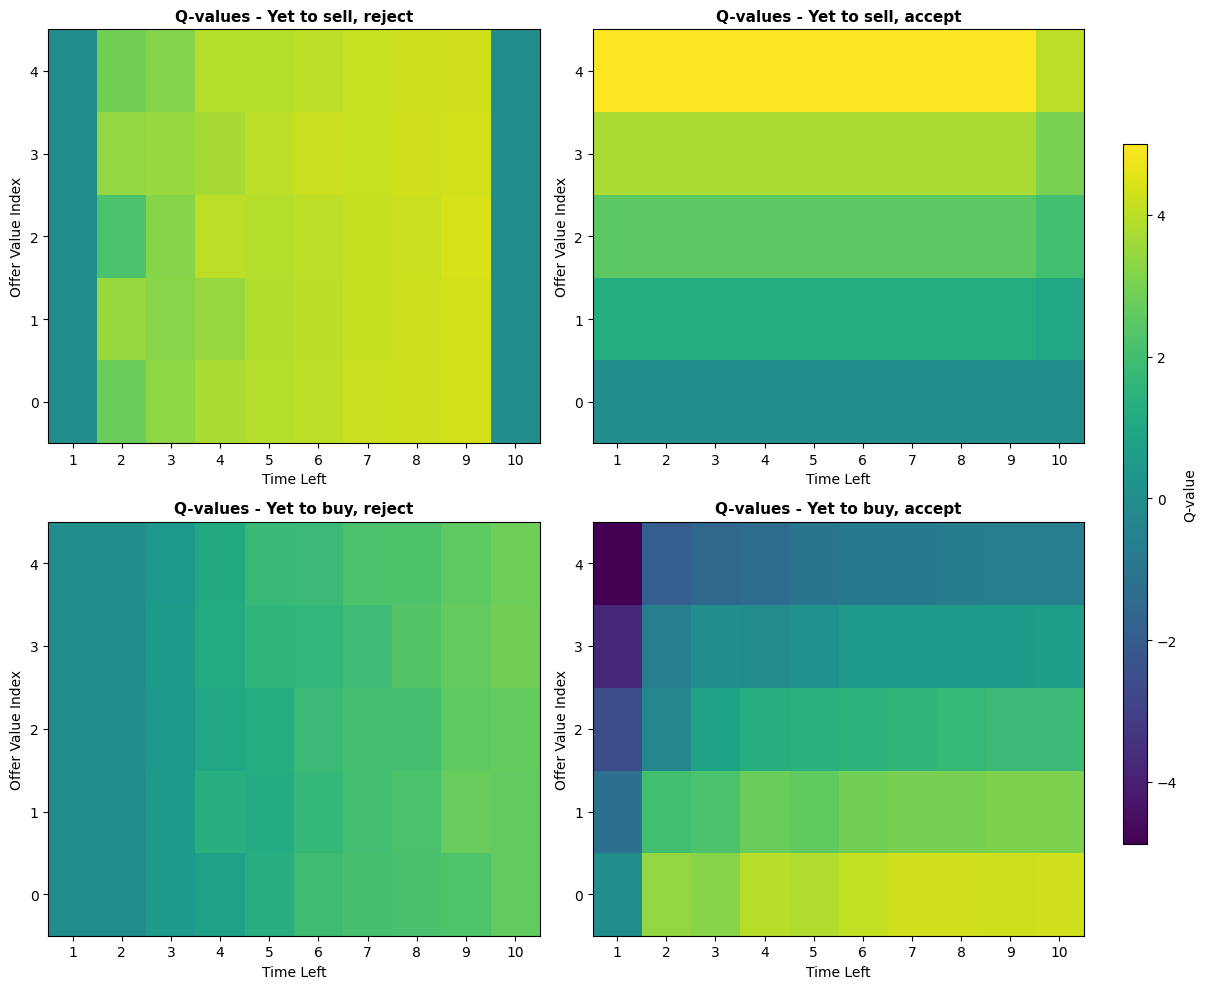

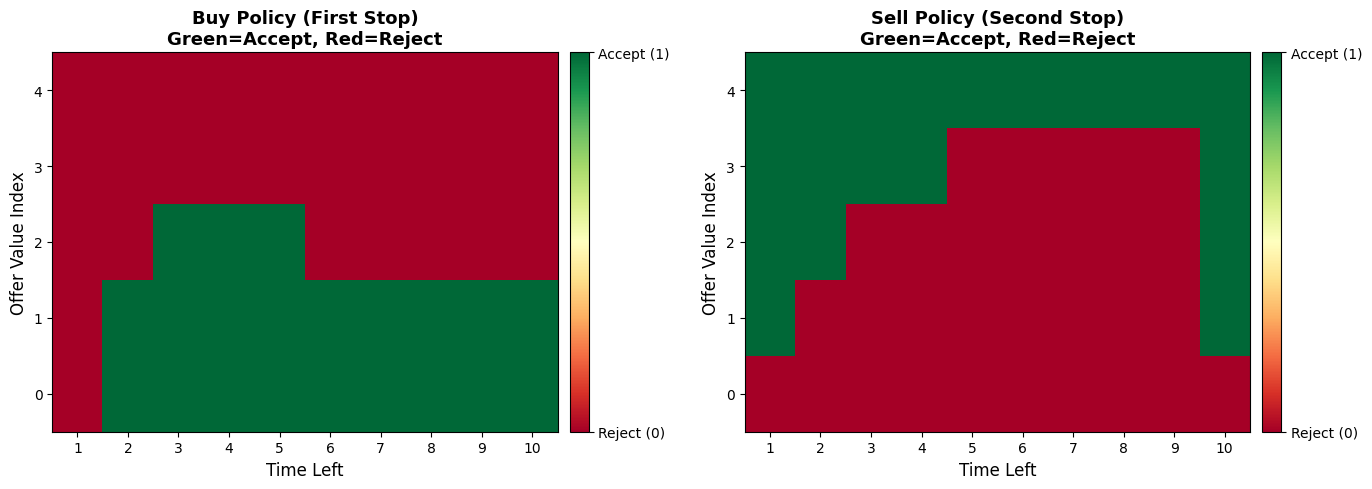


Q-Learning Policy Statistics:
Buy Policy - Accept rate: 42.00%
Sell Policy - Accept rate: 40.00%


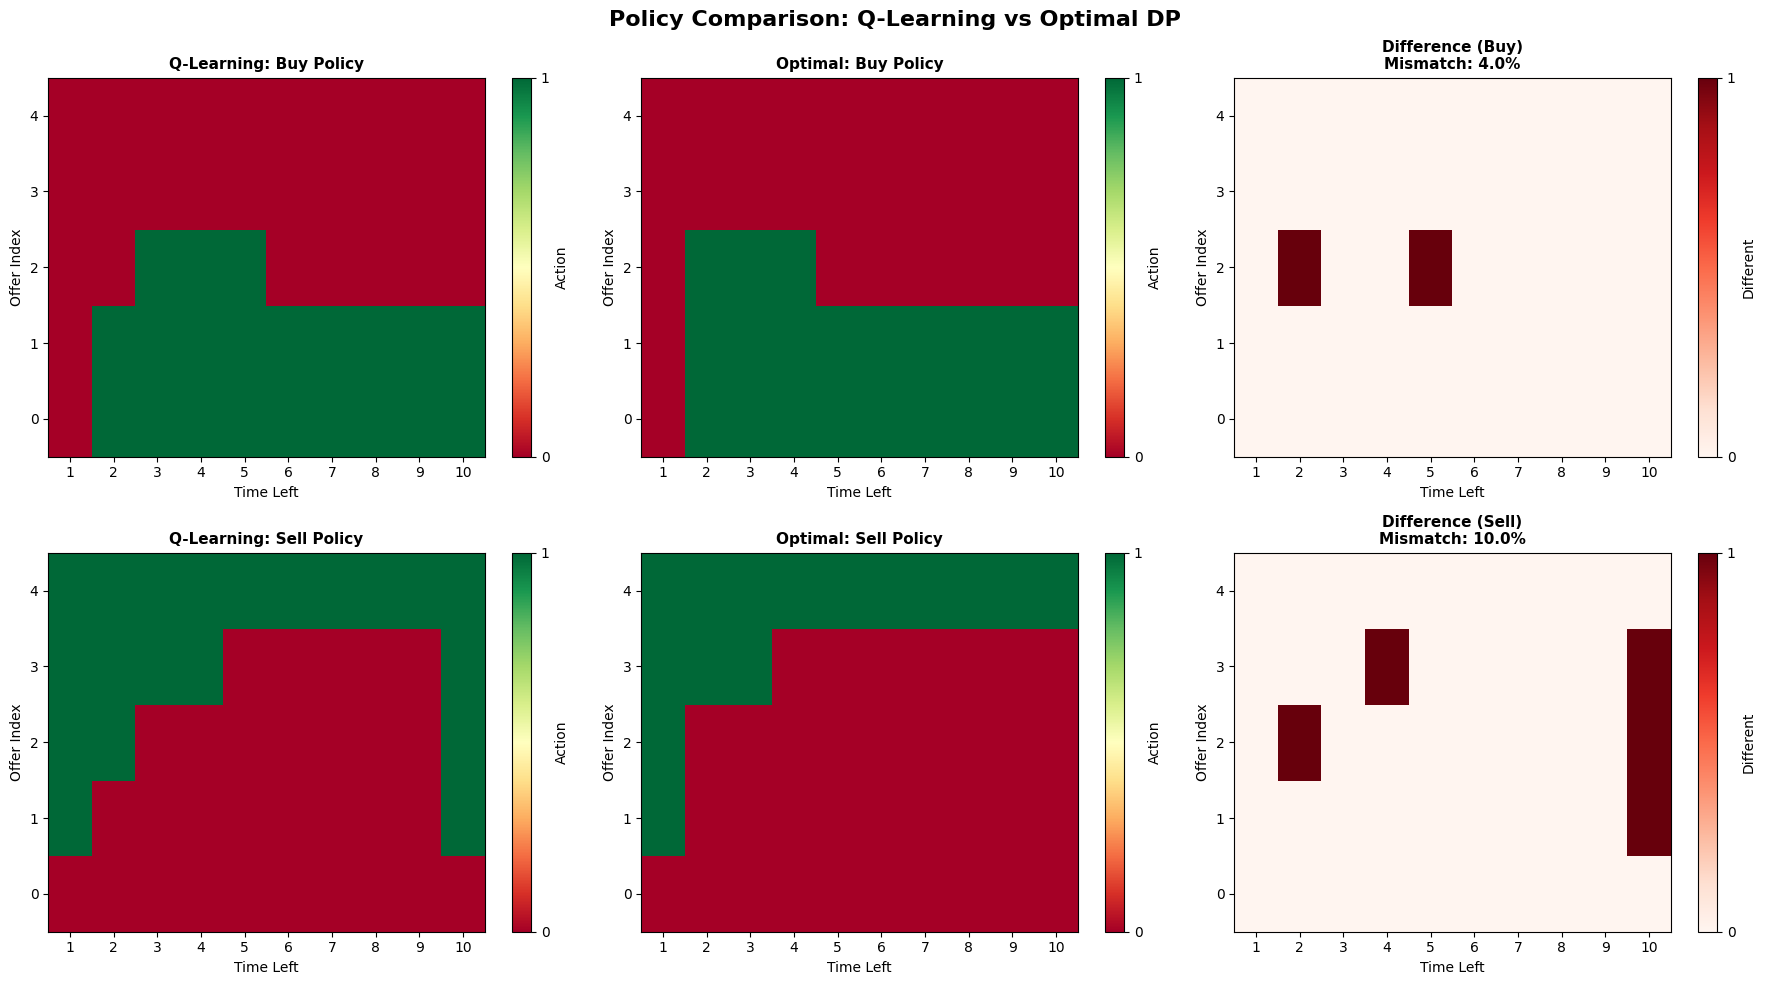


Policy Comparison Statistics

Buy Policy (stops_left=2):
  Q-Learning accept rate: 42.00%
  Optimal accept rate: 42.00%
  Agreement: 96.00%
  Mismatch: 4.00%

Sell Policy (stops_left=1):
  Q-Learning accept rate: 40.00%
  Optimal accept rate: 30.00%
  Agreement: 90.00%
  Mismatch: 10.00%

Overall Policy Agreement: 93.00%


In [7]:
viz.pipeline(compare_optimal=True)  

✓ Optimal policy computed via DP
  Max stops: 2
  Expected value at start: 3.2932
  Buy (stop 1) accept rate: 42.00%
  Sell (stop 2) accept rate: 30.00%


Evaluating Q-Learning: 100%|██████████| 100000/100000 [00:06<00:00, 15956.59it/s]




Evaluation Summary: Q-Learning
Episodes: 100000

Reward Statistics:
  Mean:          2.3969
  Std:           1.2433
  Sharpe:        1.9278
  Median:        2.3000
  Min:          -3.1000
  Max:           4.8000

Episode Length:
  Mean:            5.95
  Std:             2.65

Buy-Sell Specific Metrics:
  Completion rate:   97.35%
  Mean buy price:      1.1813
  Mean sell price:     4.0351
  Mean profit:         2.8539
  Mean holding time:     1.96



Evaluating Optimal DP: 100%|██████████| 100000/100000 [00:07<00:00, 13039.46it/s]




Evaluation Summary: Optimal DP
Episodes: 100000

Reward Statistics:
  Mean:          2.3308
  Std:           1.4724
  Sharpe:        1.5830
  Median:        2.7500
  Min:          -3.3000
  Max:           4.8000

Episode Length:
  Mean:            7.38
  Std:             2.34

Buy-Sell Specific Metrics:
  Completion rate:   96.47%
  Mean buy price:      1.1793
  Mean sell price:     4.3026
  Mean profit:         3.1255
  Mean holding time:     3.43


Policy Comparison: Q-Learning vs Optimal DP

Metric                         Q-Learning      Optimal DP     Difference       Winner
----------------------------------------------------------------------
Mean Reward                        2.3969          2.3308   -0.0661 (-2.8%)   Q-Learning
Std Reward                         1.2433          1.4724   +0.2291 (+18.4%)   Q-Learning
Sharpe Ratio                       1.9278          1.5830   -0.3448 (-17.9%)   Q-Learning
Median Reward                      2.3000          2.7500   +0.4500 (+19.

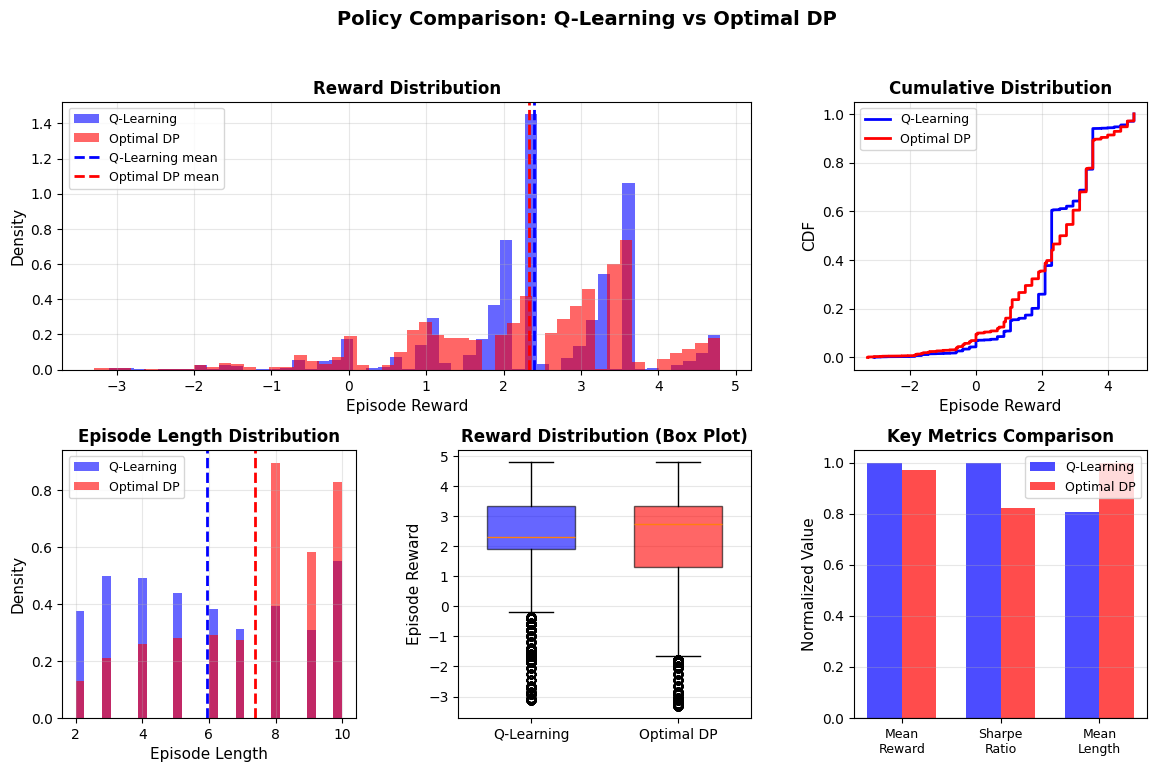

In [28]:
opt_policy = env.solve_optimal_policy()[1]
q_policy = agent.get_policy()
evaluator = PolicyEvaluator(env=buy_sell_simple_env)
# print("Q-Learning Policy Evaluation:")
evaluator.compare_policies(q_policy, opt_policy, n_episodes=100000, policy1_name="Q-Learning", policy2_name="Optimal DP")
evaluator.plot_comparison()

### Larger example

In [ ]:
bigger_env = BuySellEnv(n_states=10, max_time=5, transition_model='random_walk', transition_params={'p_up':0.2, 'p_down':0.6}, holding_cost_per_step=0.0)
sched = linear_decay_schedule(1.0, 0.1, 2000)
bigger_agent = QLearningAgent(env=bigger_env, alpha=0.1, epsilon_schedule=sched)
bigger_results = bigger_agent.train(env=bigger_env, n_episodes=50000, verbose=0, use_tqdm=True)
bigger_viz = visualizer(bigger_env, bigger_agent)
bigger_viz.pipeline(compare_optimal=True)

In [ ]:
opt_policy = bigger_env.solve_optimal_policy()[1]
q_policy = bigger_agent.get_policy()
evaluator = PolicyEvaluator(env=bigger_env)
evaluator.compare_policies(q_policy, opt_policy, policy1_name="Q-Learning", policy2_name="Optimal DP")
evaluator.plot_comparison()


### Testing Suite for IID Distributions

In [ ]:
# Test Suite: Compare Q-learning vs Optimal across different IID distributions

def run_test(test_name, n_states, max_time, holding_cost, transition_model, transition_params, 
             train_episodes=5000, eval_episodes=1000, seed=None, verbose=True, show_viz=True):
    """
    Run a single test: train Q-learning and compare with optimal policy.
    
    Returns:
        dict with test results
    """
    if verbose:
        print(f"\n{'='*70}")
        print(f"Test: {test_name}")
        print(f"{'='*70}")
    
    # Create environment
    env = BuySellEnv(
        n_states=n_states,
        max_time=max_time,
        holding_cost_per_step=holding_cost,
        transition_model=transition_model,
        transition_params=transition_params,
        seed=seed
    )
    
    # Train Q-learning
    epsilon_schedule = linear_decay_schedule(1.0, 0.05, train_episodes // 2)
    agent = QLearningAgent(env=env, alpha=0.1, epsilon_schedule=epsilon_schedule, gamma=1.0)
    agent.train(env, n_episodes=train_episodes, verbose=0, use_tqdm=verbose)
    
    # Get policies
    q_policy = agent.get_policy()
    V_opt, opt_policy = env.solve_optimal_policy(verbose=False)
    
    # Quick evaluation (just mean rewards)
    evaluator = PolicyEvaluator(env)
    results_q = evaluator.evaluate_policy(q_policy, n_episodes=eval_episodes, 
                                          policy_name="Q-Learning", verbose=False, seed=seed)
    results_opt = evaluator.evaluate_policy(opt_policy, n_episodes=eval_episodes, 
                                           policy_name="Optimal", verbose=False, seed=seed)
    
    if verbose:
        print(f"  Q-Learning Mean Reward: {results_q['mean_reward']:.4f}")
        print(f"  Optimal Mean Reward:    {results_opt['mean_reward']:.4f}")
        print(f"  Performance Ratio:      {results_q['mean_reward']/results_opt['mean_reward']:.2%}")
    
    # Compute metrics
    performance_ratio = results_q['mean_reward'] / results_opt['mean_reward'] if results_opt['mean_reward'] != 0 else 0
    policy_agreement = np.mean(q_policy == opt_policy)
    
    # Visualize policies
    if show_viz:
        viz = visualizer(env, agent, optimal_policy=opt_policy)
        viz.compare_with_optimal()
    
    return {
        'test_name': test_name,
        'q_results': results_q,
        'opt_results': results_opt,
        'evaluator': evaluator,
        'performance_ratio': performance_ratio,
        'policy_agreement': policy_agreement,
        'env': env,
        'agent': agent
    }

In [ ]:
# Define test cases
test_configs = [
    # Uniform distributions (different ranges)
    ('Uniform_Full', 'iid', None),
    ('Uniform_CenterBias', 'iid', {'prob': np.array([0.05, 0.08, 0.12, 0.15, 0.2, 0.2, 0.15, 0.12, 0.08, 0.05])}),
    ('Uniform_EdgeBias', 'iid', {'prob': np.array([0.15, 0.12, 0.08, 0.05, 0.05, 0.05, 0.05, 0.08, 0.12, 0.25])}),
    
    # Gaussian distributions
    ('Gaussian_Centered', 'iid_gaussian', {'mean': 5.0, 'std': 2.0}),
    ('Gaussian_LeftSkewed', 'iid_gaussian', {'mean': 3.0, 'std': 1.5}),
    ('Gaussian_RightSkewed', 'iid_gaussian', {'mean': 7.0, 'std': 1.5}),
    ('Gaussian_Narrow', 'iid_gaussian', {'mean': 5.0, 'std': 1.0}),
    ('Gaussian_Wide', 'iid_gaussian', {'mean': 5.0, 'std': 3.0}),
    
    # Custom IID distributions
    ('Bimodal', 'iid', {'prob': np.array([0.3, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.3])}),
    ('LeftHeavy', 'iid', {'prob': np.array([0.4, 0.3, 0.15, 0.08, 0.04, 0.02, 0.005, 0.003, 0.001, 0.001])}),
    ('RightHeavy', 'iid', {'prob': np.array([0.001, 0.001, 0.003, 0.005, 0.02, 0.04, 0.08, 0.15, 0.3, 0.4])}),
]

print(f"Configured {len(test_configs)} test cases")

In [ ]:
# Run tests (quick version with 3 distributions)
quick_tests = test_configs[:3]  # Three uniform variations
quick_results = {}

for test_name, trans_model, trans_params in quick_tests:
    result = run_test(
        test_name=test_name,
        n_states=10,
        max_time=20,
        holding_cost=0.05,
        transition_model=trans_model,
        transition_params=trans_params,
        train_episodes=5000,
        eval_episodes=500,
        seed=42,
        verbose=True,
        show_viz=True  # Show policy visualizations
    )
    quick_results[test_name] = result

print("\n" + "="*70)
print("Quick Test Summary")
print("="*70)
for name, res in quick_results.items():
    print(f"{name:25} | Performance: {res['performance_ratio']:6.2%} | "
          f"Sharpe Q/Opt: {res['q_results']['sharpe_ratio']:.3f}/{res['opt_results']['sharpe_ratio']:.3f} | "
          f"Agreement: {res['policy_agreement']:.1%}")

#### Visualize Quick Test Results

In [ ]:
# Plot comparison of quick tests
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

test_names = list(quick_results.keys())
q_rewards = [quick_results[name]['q_results']['mean_reward'] for name in test_names]
opt_rewards = [quick_results[name]['opt_results']['mean_reward'] for name in test_names]
q_sharpe = [quick_results[name]['q_results']['sharpe_ratio'] for name in test_names]
opt_sharpe = [quick_results[name]['opt_results']['sharpe_ratio'] for name in test_names]
perf_ratios = [quick_results[name]['performance_ratio'] for name in test_names]

x = np.arange(len(test_names))
width = 0.35

# Mean rewards
axes[0].bar(x - width/2, q_rewards, width, label='Q-Learning', alpha=0.7, color='blue')
axes[0].bar(x + width/2, opt_rewards, width, label='Optimal', alpha=0.7, color='red')
axes[0].set_ylabel('Mean Reward')
axes[0].set_title('Mean Reward Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(test_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Sharpe ratios
axes[1].bar(x - width/2, q_sharpe, width, label='Q-Learning', alpha=0.7, color='blue')
axes[1].bar(x + width/2, opt_sharpe, width, label='Optimal', alpha=0.7, color='red')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].set_title('Sharpe Ratio Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(test_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# Performance ratio
axes[2].bar(x, perf_ratios, alpha=0.7, color='green')
axes[2].axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='100%')
axes[2].set_ylabel('Q-Learning / Optimal')
axes[2].set_title('Performance Ratio')
axes[2].set_xticks(x)
axes[2].set_xticklabels(test_names, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# Examine a specific test in detail
test_to_examine = 'Gaussian_Centered'
if test_to_examine in quick_results:
    print(f"\nDetailed analysis of: {test_to_examine}")
    quick_results[test_to_examine]['evaluator'].plot_comparison()

In [ ]:
# Save results (optional)
# suite_full.save_results('test_results_iid_distributions.json')

#### Optional: Run Full Test Suite (All 9 Distributions)

#### Optional: Run Full Test Suite (All 11 Distributions)

Uncomment to run full test suite with policy visualizations:

```python
full_results = {}

for test_name, trans_model, trans_params in test_configs:
    result = run_test(
        test_name=test_name,
        n_states=10,
        max_time=20,
        holding_cost=0.05,
        transition_model=trans_model,
        transition_params=trans_params,
        train_episodes=10000,
        eval_episodes=1000,
        seed=42,
        verbose=True,
        show_viz=True  # Show policy visualizations for each test
    )
    full_results[test_name] = result

# Summary
print("\n" + "="*70)
print("Full Test Summary")
print("="*70)
for name, res in full_results.items():
    print(f"{name:25} | Performance: {res['performance_ratio']:6.2%} | "
          f"Sharpe Q/Opt: {res['q_results']['sharpe_ratio']:.3f}/{res['opt_results']['sharpe_ratio']:.3f} | "
          f"Agreement: {res['policy_agreement']:.1%}")
```

#### Custom Distribution Testing

In [ ]:
# # Example: Single custom test with exponential distribution
# custom_result = run_test(
#     test_name='Custom_Exponential',
#     n_states=10,
#     max_time=20,
#     holding_cost=0.05,
#     transition_model='iid',
#     transition_params={'prob': np.exp(-np.arange(10)/3) / np.exp(-np.arange(10)/3).sum()},
#     train_episodes=5000,
#     eval_episodes=500,
#     seed=42,
#     verbose=True
# )

# # Visualize
# custom_result['evaluator'].plot_comparison()

### Markov Setting

#### Highly Biased Random Walk 

In [ ]:
markov_env = BuySellEnv(
    n_states=5,
    max_time=10,
    holding_cost_per_step=0.05,
    transition_model='random_walk',
    transition_params={'p_up': 0.6, 'p_down': 0.4},
    seed=42
)

In [ ]:
# n_eps = 1000000
# sched = linear_decay_schedule(1.0, 0.5, n_eps)
# agent_markov = QLearningAgent(env=markov_env, alpha_schedule=sched, epsilon_schedule=sched, gamma=1.0)
# agent_markov.train(markov_env, n_episodes=n_eps, verbose=0, use_tqdm=True)
# viz_markov = visualizer(markov_env, agent_markov)
# viz_markov.pipeline(compare_optimal=True)


### Testing Q-Learning: Regular vs Max-Info

We'll test two Q-Learning approaches on a simple **accept-reward problem** (like the secretary problem):

**Approach 1: Regular Q-Learning**
- Uses epsilon-greedy exploration
- Can accept offers at any time during training
- May terminate episodes early

**Approach 2: Max-Info Q-Learning**
- Forces rejection until the last time step during training
- Observes all states in every episode
- Should learn better value estimates for reject actions

**Environment:** AcceptRewardEnv
- Single stopping problem (accept once and receive reward)
- Reward = offer value when accepting
- No costs or penalties
- Classic optimal stopping problem

Approach 1: Standard Q learning with the epsilon greedy policy.
Approach 2: Optimising for maximum information gain - keep rejecting offer till the final offer.

For same number of episodes on each one, calculate which one is likely to learn the optimal solution better. 

In [ ]:
# Import the max-info Q-learning variant and accept-reward environment
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.resolve()))

from algorithms.q_learning_max_info import QLearningMaxInfo
from accept_reward_env import AcceptRewardEnv

In [ ]:
# Create a simple accept-reward environment (classic secretary/house-hunting problem)
accept_env = AcceptRewardEnv(
    n_states=10,
    max_time=20,
    transition_model='iid_gaussian',
    transition_params={'mean': 5.0, 'std': 2.0},
    seed=42
)

print(f"Environment: {accept_env.n_states} states, {accept_env.max_time} time steps")
print(f"Offer values: {accept_env.offer_values}")
print(f"Problem: Accept one offer to maximize expected reward")

In [ ]:
# Training parameters
n_episodes = 10000
epsilon_schedule = linear_decay_schedule(1.0, 0.05, n_episodes // 2)
alpha_schedule = linear_decay_schedule(0.3, 0.05, n_episodes // 2)

print(f"\nTraining both approaches for {n_episodes} episodes...")
print("="*70)

# Approach 1: Regular Q-Learning
print("\n1. Training Regular Q-Learning (epsilon-greedy)...")
agent_regular = QLearningAgent(
    env=accept_env,
    alpha_schedule=alpha_schedule,
    epsilon_schedule=epsilon_schedule,
    gamma=1.0,
    seed=42
)
agent_regular.train(accept_env, n_episodes=n_episodes, verbose=0, use_tqdm=True)

# Approach 2: Max-Info Q-Learning
print("\n2. Training Max-Info Q-Learning (reject until last step)...")
agent_max_info = QLearningMaxInfo(
    env=accept_env,
    alpha_schedule=alpha_schedule,
    epsilon_schedule=epsilon_schedule,
    gamma=1.0,
    seed=42
)
agent_max_info.train(accept_env, n_episodes=n_episodes, verbose=0, use_tqdm=True)

print("\n" + "="*70)
print("Training complete!")

In [ ]:
# Get optimal policy
print("\nComputing optimal policy...")
V_opt, opt_policy = accept_env.solve_optimal_policy(verbose=True)

# Get learned policies
regular_policy = agent_regular.get_policy()
max_info_policy = agent_max_info.get_policy()

# Evaluate all three policies
print("\nEvaluating policies...")
evaluator_accept = PolicyEvaluator(accept_env)

results_regular = evaluator_accept.evaluate_policy(
    regular_policy,
    n_episodes=1000,
    policy_name="Regular Q-Learning",
    verbose=False,
    seed=42
)

results_max_info = evaluator_accept.evaluate_policy(
    max_info_policy,
    n_episodes=1000,
    policy_name="Max-Info Q-Learning",
    verbose=False,
    seed=42
)

results_optimal = evaluator_accept.evaluate_policy(
    opt_policy,
    n_episodes=1000,
    policy_name="Optimal",
    verbose=False,
    seed=42
)

In [ ]:
# Compute policy agreement with optimal
agreement_regular = np.mean(regular_policy == opt_policy)
agreement_max_info = np.mean(max_info_policy == opt_policy)

# Print comprehensive comparison
print("\n" + "="*80)
print("COMPARISON RESULTS: Regular Q-Learning vs Max-Info Q-Learning")
print("="*80)

print("\n1. PERFORMANCE (Evaluation Rewards)")
print("-" * 80)
print(f"{'Method':<30} {'Mean Reward':<15} {'Std':<10} {'Sharpe':<10} {'vs Optimal'}")
print("-" * 80)
print(f"{'Regular Q-Learning':<30} {results_regular['mean_reward']:<15.4f} "
      f"{results_regular['std_reward']:<10.4f} {results_regular['sharpe_ratio']:<10.4f} "
      f"{results_regular['mean_reward']/results_optimal['mean_reward']:>8.2%}")
print(f"{'Max-Info Q-Learning':<30} {results_max_info['mean_reward']:<15.4f} "
      f"{results_max_info['std_reward']:<10.4f} {results_max_info['sharpe_ratio']:<10.4f} "
      f"{results_max_info['mean_reward']/results_optimal['mean_reward']:>8.2%}")
print(f"{'Optimal':<30} {results_optimal['mean_reward']:<15.4f} "
      f"{results_optimal['std_reward']:<10.4f} {results_optimal['sharpe_ratio']:<10.4f} "
      f"{'100.0%':>8}")

improvement = ((results_max_info['mean_reward'] - results_regular['mean_reward']) / 
               results_regular['mean_reward'] * 100)
print(f"\nMax-Info improvement over Regular: {improvement:+.2f}%")

print("\n2. POLICY AGREEMENT WITH OPTIMAL")
print("-" * 80)
print(f"Regular Q-Learning:    {agreement_regular:.2%}")
print(f"Max-Info Q-Learning:   {agreement_max_info:.2%}")
print(f"Difference:            {(agreement_max_info - agreement_regular)*100:+.2f} percentage points")

print("\n3. LEARNING STATISTICS")
print("-" * 80)
print(f"Regular Q-Learning:")
print(f"  - Final 100-ep avg reward: {np.mean(agent_regular.episode_rewards[-100:]):.4f}")
print(f"  - Visit counts (states):   {agent_regular.visit_counts.sum():.0f} total visits")

print(f"\nMax-Info Q-Learning:")
print(f"  - Final 100-ep avg reward: {np.mean(agent_max_info.episode_rewards[-100:]):.4f}")
print(f"  - Visit counts (states):   {agent_max_info.visit_counts.sum():.0f} total visits")
print(f"  - Total forced rejects:    {agent_max_info.total_forced_rejects}")

print("\n" + "="*80)

In [ ]:
# Visualize policies side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Single-Stopping Policy Comparison', fontsize=16, fontweight='bold')

# Exclude time_left=0
regular_view = regular_policy[:, 1:, 1]
max_info_view = max_info_policy[:, 1:, 1]
opt_view = opt_policy[:, 1:, 1]

max_time = regular_view.shape[1]
time_ticks = np.arange(0, max_time, max(1, max_time//10))
time_labels = np.arange(1, max_time+1, max(1, max_time//10))

# Regular Q-Learning
im1 = axes[0].imshow(regular_view, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[0].set_title(f'Regular Q-Learning\nAgreement: {agreement_regular:.1%}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Left', fontsize=11)
axes[0].set_ylabel('Offer Index', fontsize=11)
axes[0].set_xticks(time_ticks)
axes[0].set_xticklabels(time_labels)
cbar1 = plt.colorbar(im1, ax=axes[0], ticks=[0, 1])
cbar1.set_ticklabels(['Reject', 'Accept'])

# Max-Info Q-Learning
im2 = axes[1].imshow(max_info_view, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[1].set_title(f'Max-Info Q-Learning\nAgreement: {agreement_max_info:.1%}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Left', fontsize=11)
axes[1].set_ylabel('Offer Index', fontsize=11)
axes[1].set_xticks(time_ticks)
axes[1].set_xticklabels(time_labels)
cbar2 = plt.colorbar(im2, ax=axes[1], ticks=[0, 1])
cbar2.set_ticklabels(['Reject', 'Accept'])

# Optimal
im3 = axes[2].imshow(opt_view, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[2].set_title('Optimal Policy', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Time Left', fontsize=11)
axes[2].set_ylabel('Offer Index', fontsize=11)
axes[2].set_xticks(time_ticks)
axes[2].set_xticklabels(time_labels)
cbar3 = plt.colorbar(im3, ax=axes[2], ticks=[0, 1])
cbar3.set_ticklabels(['Reject', 'Accept'])

plt.tight_layout()
plt.show()

In [ ]:
# Difference heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

regular_view = regular_policy[:, 1:, 1]
max_info_view = max_info_policy[:, 1:, 1]
opt_view = opt_policy[:, 1:, 1]

# Difference: Regular vs Optimal
diff_regular = (regular_view != opt_view).astype(float)
im1 = axes[0].imshow(diff_regular, cmap='Reds', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[0].set_title(f'Regular Q-Learning vs Optimal\nMismatch: {diff_regular.mean():.1%}', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Time Left', fontsize=11)
axes[0].set_ylabel('Offer Index', fontsize=11)
axes[0].set_xticks(time_ticks)
axes[0].set_xticklabels(time_labels)
plt.colorbar(im1, ax=axes[0], ticks=[0, 1], label='Different')

# Difference: Max-Info vs Optimal
diff_max_info = (max_info_view != opt_view).astype(float)
im2 = axes[1].imshow(diff_max_info, cmap='Reds', vmin=0, vmax=1, aspect='auto', origin='lower')
axes[1].set_title(f'Max-Info Q-Learning vs Optimal\nMismatch: {diff_max_info.mean():.1%}', 
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Left', fontsize=11)
axes[1].set_ylabel('Offer Index', fontsize=11)
axes[1].set_xticks(time_ticks)
axes[1].set_xticklabels(time_labels)
plt.colorbar(im2, ax=axes[1], ticks=[0, 1], label='Different')

plt.tight_layout()
plt.show()

print(f"\nPolicy Mismatch Summary:")
print(f"  Regular vs Optimal:  {diff_regular.mean():.2%}")
print(f"  Max-Info vs Optimal: {diff_max_info.mean():.2%}")
print(f"  Winner: {'Max-Info' if diff_max_info.mean() < diff_regular.mean() else 'Regular'}")

In [ ]:
# Learning curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

window = 100
regular_rewards = np.convolve(
    agent_regular.episode_rewards,
    np.ones(window)/window, mode='valid'
)
max_info_rewards = np.convolve(
    agent_max_info.episode_rewards,
    np.ones(window)/window, mode='valid'
)

# Learning curves
axes[0].plot(regular_rewards, label='Regular Q-Learning', alpha=0.8, linewidth=2)
axes[0].plot(max_info_rewards, label='Max-Info Q-Learning', alpha=0.8, linewidth=2)
axes[0].axhline(y=results_optimal['mean_reward'], color='red', linestyle='--', 
                linewidth=2, label='Optimal', alpha=0.7)
axes[0].set_xlabel('Episode', fontsize=11)
axes[0].set_ylabel(f'Average Reward ({window}-ep window)', fontsize=11)
axes[0].set_title('Learning Curves', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Final performance comparison
methods = ['Regular\nQ-Learning', 'Max-Info\nQ-Learning', 'Optimal']
mean_rewards = [
    results_regular['mean_reward'],
    results_max_info['mean_reward'],
    results_optimal['mean_reward']
]
std_rewards = [
    results_regular['std_reward'],
    results_max_info['std_reward'],
    results_optimal['std_reward']
]
colors = ['blue', 'green', 'red']

axes[1].bar(methods, mean_rewards, yerr=std_rewards, capsize=5, alpha=0.7, color=colors)
axes[1].set_ylabel('Mean Reward', fontsize=11)
axes[1].set_title('Performance Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()